# Galactic Chemical Evolution within NIHAO-UHD Simulations

Comparing the galactic chemical evolution in a NIHAO-UHD Milky-Way analogue simulation and the actual Milky Way.

### Github Repository:

https://www.github.com/svenbuder/nmf_nihao

In [3]:
try:
    %matplotlib inline
    %config InlineBackend.figure_format='retina'
except:
    pass

# general packages
import numpy as np
from astropy.table import Table
from astropy.cosmology import Planck15 as cosmo
import glob
from pathlib import Path

# matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, LinearSegmentedColormap
from matplotlib.patches import Circle
from matplotlib import rcParams
rcParams['axes.labelsize'] = 15
rcParams['legend.fontsize'] = 15
rcParams['figure.titlesize'] = 20

panels = [
    'a)','b)','c)',
    'd)','e)','f)',
    'g)','h)','i)',
    'j)','k)','l)',
    'm)','n)','o)',
    'q)','r)','s)',
    't)','u)','v)',
    'w)','x)','y)',
    'z)','aa)','ab)',
    'ac)','ad)','ae)'
]

# Simulations

In [4]:
simulation_name = 'NIHAO_g8.26e11_pilot'

# The following file is available at: https://www.mso.anu.edu.au/~buder/NIHAO_prepared/NIHAO_g8.26e11_pilot_stars.fits
stars       = Table.read('data/'+simulation_name+'_stars.fits')

## Chemistry in simulation

In [5]:
def optimal_grid(num_elements):
    # Find the optimal grid size (rows, cols) for num_elements
    rows = int(np.floor(np.sqrt(num_elements)))
    cols = int(np.ceil(num_elements / rows))
    if rows * cols < num_elements:
        rows += 1
    return rows, cols

print('Looping through elements H, He, Li, ... Eu, Gd to identify elements in simulation')
elements_in_simulation = []

for element in stars.keys():
    if element[-2:] == '_H':
        elements_in_simulation.append(element[:-2])
        
print('Elements in simulation: ',elements_in_simulation)

Looping through elements H, He, Li, ... Eu, Gd to identify elements in simulation
Elements in simulation:  ['He', 'C', 'N', 'O', 'Ne', 'Mg', 'Al', 'Si', 'P', 'S', 'V', 'Cr', 'Mn', 'Fe', 'Co', 'Ba']


Saved as NIHAO_g8.26e11_pilot_nucleosynthesis_channels.png


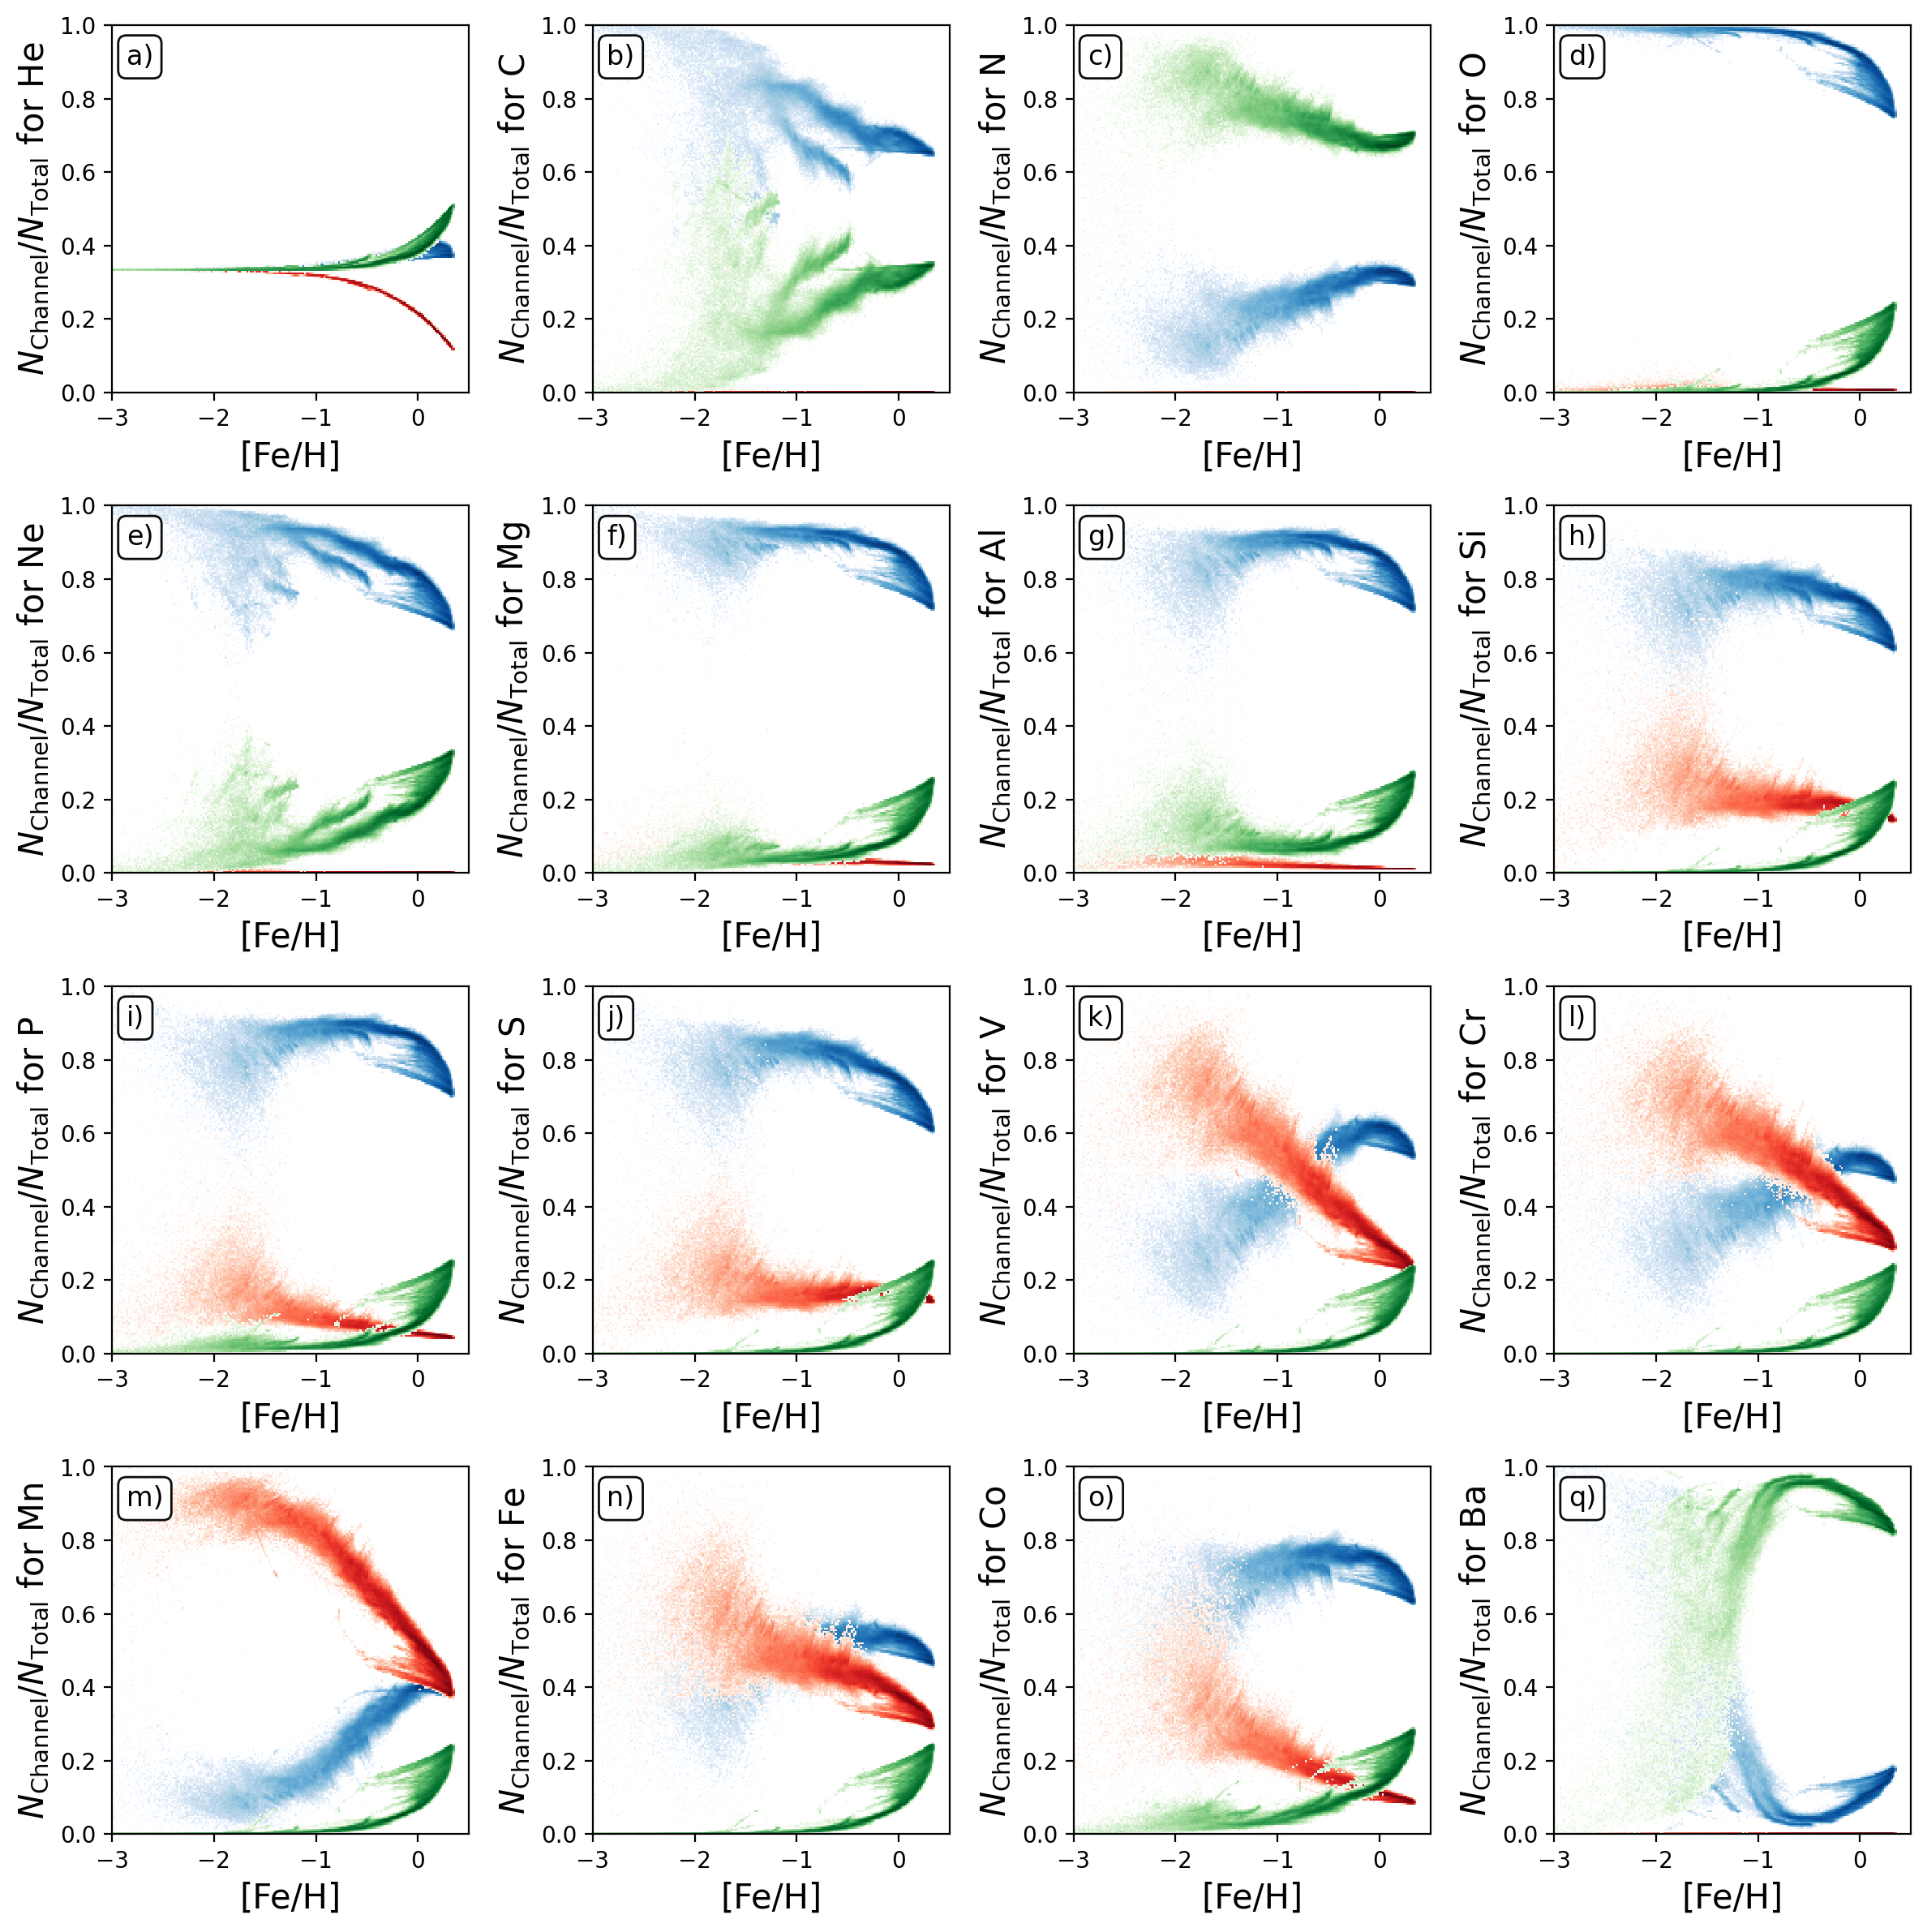

In [6]:
def plot_channel_contributions(ymin = -6.0, ymax = 1.0, bins = 200, saveas=False):    
    
    rows, cols = optimal_grid(len(elements_in_simulation))
    
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols,3*rows))
    axes = axes.flatten()
    
    for i, element in enumerate(elements_in_simulation):
        
        ax = axes[i]
        ax.text(0.04,0.95,panels[i],fontsize=12,transform=ax.transAxes,va='top',ha='left',bbox=dict(boxstyle='round', facecolor='w', alpha=0.95))
        ax.set_xlabel('[Fe/H]',fontsize=15)
        ax.set_ylabel(r'$N_\mathrm{Channel} / N_\mathrm{Total}$ for '+element,fontsize=15)

        for colormap, channel in zip(['Blues','Reds','Greens'],['SNII','SNIa','AGB']):
            ax.hist2d(
                stars['Fe_H'],
                (10**stars[element+'_H_'+channel]) / (10**stars[element+'_H']),
                bins = (np.linspace(-3,0.5,bins),np.linspace(0,1, bins)), cmin = 1, norm=LogNorm(),
                cmap = colormap
            );
    plt.tight_layout()

    if saveas:
        filename = simulation_name+'_nucleosynthesis_channels.png'
        plt.savefig('figures/'+filename, dpi=400, bbox_inches='tight')
        print('Saved as '+filename)
    plt.show()
    plt.close()

plot_channel_contributions(saveas=True)

Saved as NIHAO_g8.26e11_pilot_nucleosynthesis_channels_age.png


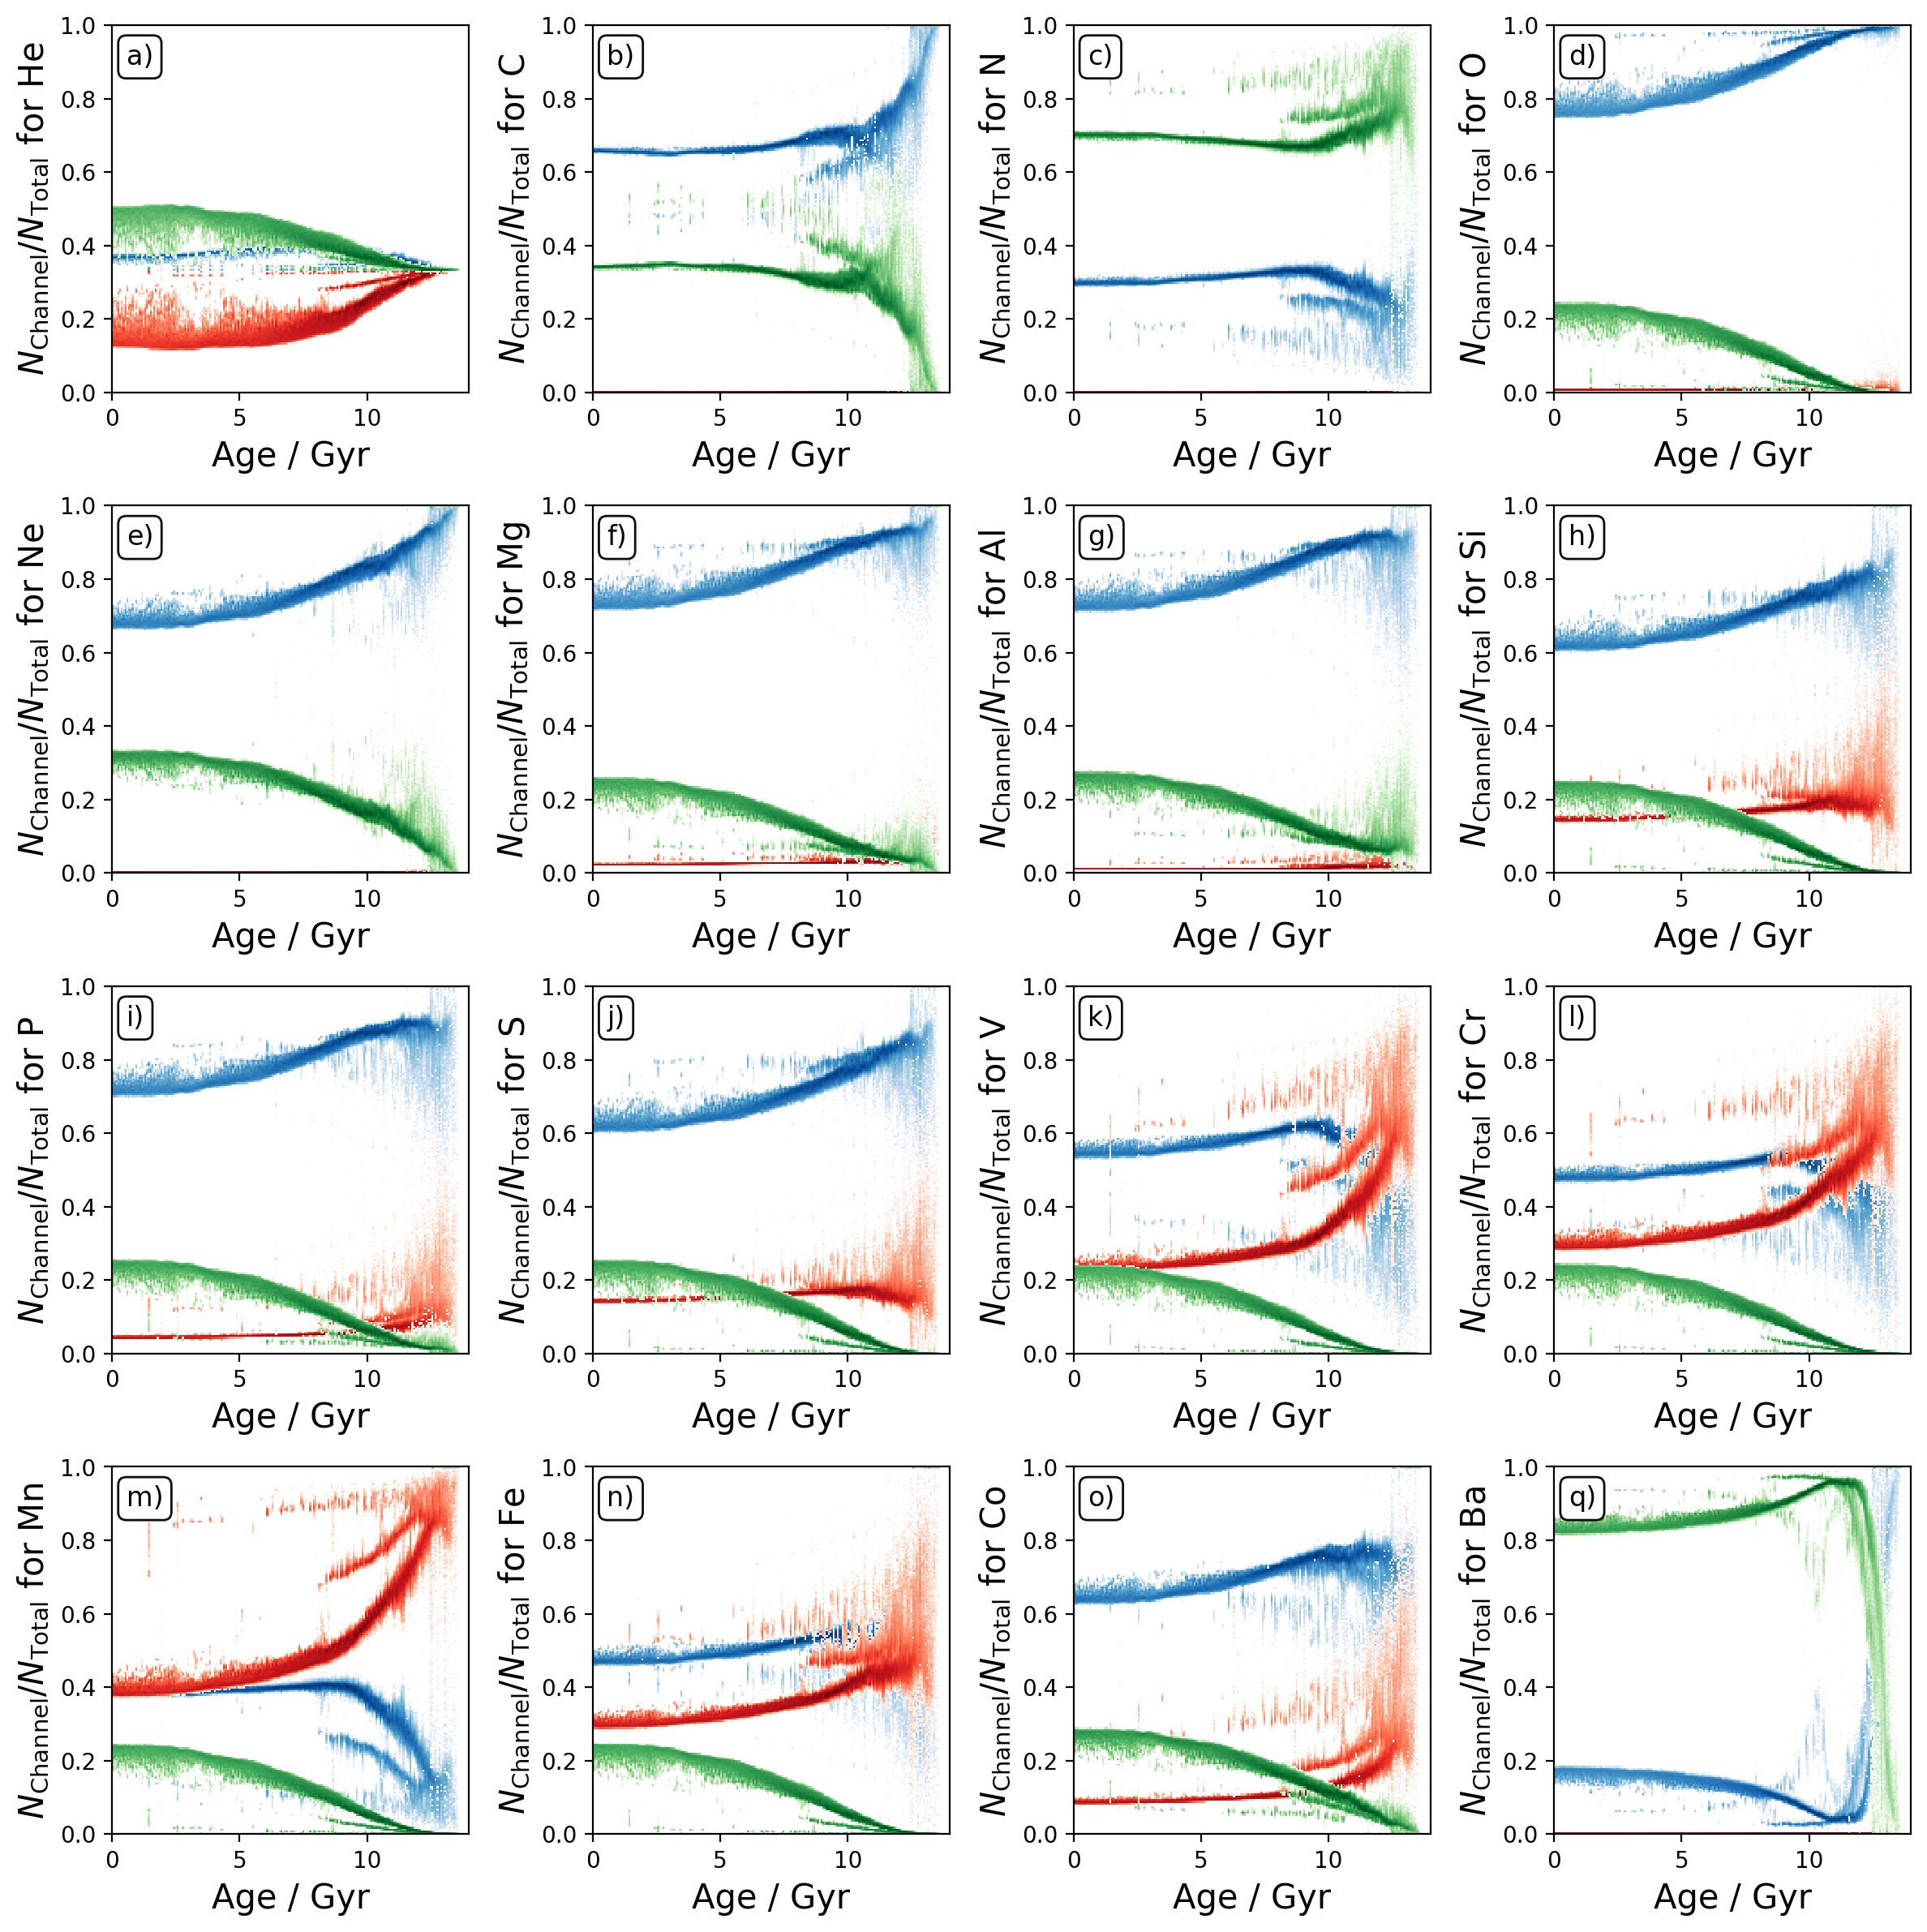

In [7]:
def plot_channel_contributions_over_time(ymin = -6.0, ymax = 1.0, bins = 200, saveas=False):    
    
    rows, cols = optimal_grid(len(elements_in_simulation))
    
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols,3*rows))
    axes = axes.flatten()
    
    for i, element in enumerate(elements_in_simulation):
        
        ax = axes[i]
        ax.text(0.04,0.95,panels[i],fontsize=12,transform=ax.transAxes,va='top',ha='left',bbox=dict(boxstyle='round', facecolor='w', alpha=0.95))
        ax.set_xlabel('Age / Gyr',fontsize=15)
        ax.set_ylabel(r'$N_\mathrm{Channel} / N_\mathrm{Total}$ for '+element,fontsize=15)

        for colormap, channel in zip(['Blues','Reds','Greens'],['SNII','SNIa','AGB']):
            ax.hist2d(
                stars['age'],
                (10**stars[element+'_H_'+channel]) / (10**stars[element+'_H']),
                bins = (np.linspace(0,14,bins),np.linspace(0,1, bins)), cmin = 1, norm=LogNorm(),
                cmap = colormap
            );
    plt.tight_layout()

    if saveas:
        filename = simulation_name+'_nucleosynthesis_channels_age.png'
        plt.savefig('figures/'+filename, dpi=400, bbox_inches='tight')
        print('Saved as '+filename)
    plt.show()
    plt.close()

plot_channel_contributions_over_time(saveas=True)

Saved as NIHAO_g8.26e11_pilot_nucleosynthesis_channels_radius.png


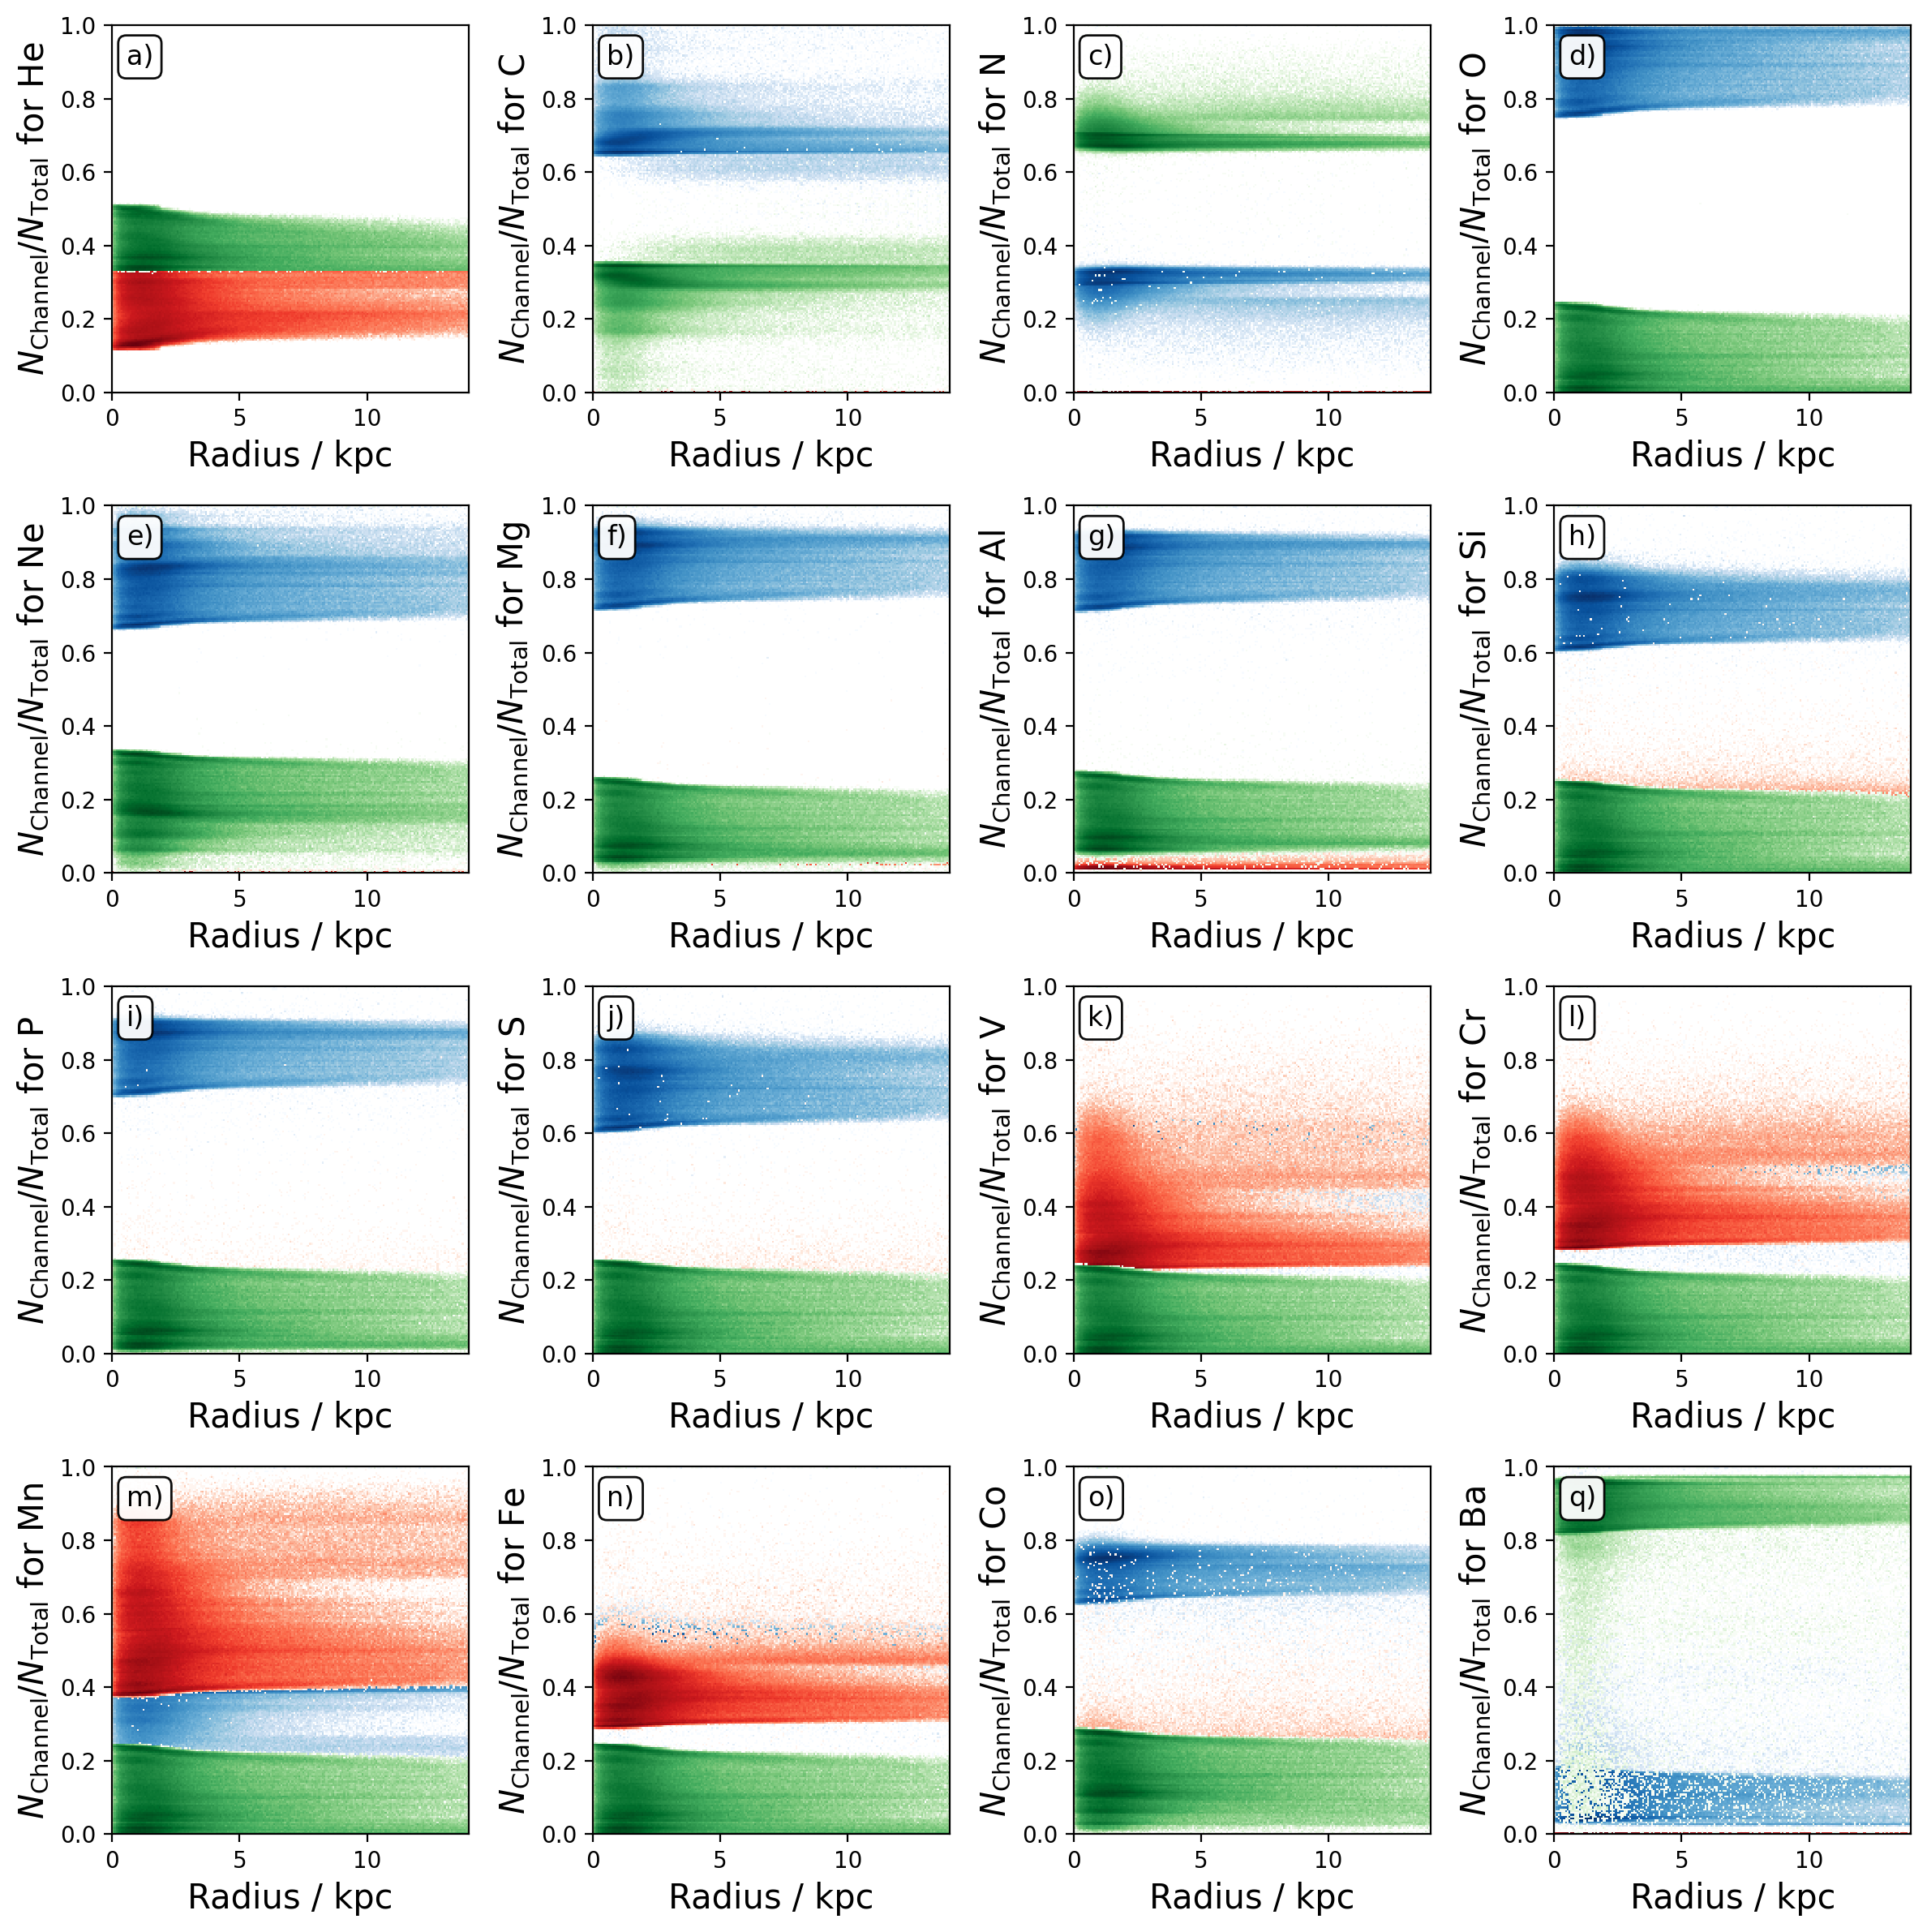

In [8]:
def plot_channel_contributions_over_radius(ymin = -6.0, ymax = 1.0, bins = 200, saveas=False):    
    
    rows, cols = optimal_grid(len(elements_in_simulation))
    
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols,3*rows))
    axes = axes.flatten()
    
    for i, element in enumerate(elements_in_simulation):
        
        ax = axes[i]
        ax.text(0.04,0.95,panels[i],fontsize=12,transform=ax.transAxes,va='top',ha='left',bbox=dict(boxstyle='round', facecolor='w', alpha=0.95))
        ax.set_xlabel('Radius / kpc',fontsize=15)
        ax.set_ylabel(r'$N_\mathrm{Channel} / N_\mathrm{Total}$ for '+element,fontsize=15)

        for colormap, channel in zip(['Blues','Reds','Greens'],['SNII','SNIa','AGB']):
            ax.hist2d(
                np.sqrt(stars['x']**2+stars['y']**2),
                (10**stars[element+'_H_'+channel]) / (10**stars[element+'_H']),
                bins = (np.linspace(0,14,bins),np.linspace(0,1, bins)), cmin = 1, norm=LogNorm(),
                cmap = colormap
            );
    plt.tight_layout()

    if saveas:
        filename = simulation_name+'_nucleosynthesis_channels_radius.png'
        plt.savefig('figures/'+filename, dpi=400, bbox_inches='tight')
        print('Saved as '+filename)
    plt.show()
    plt.close()

plot_channel_contributions_over_radius(saveas=True)

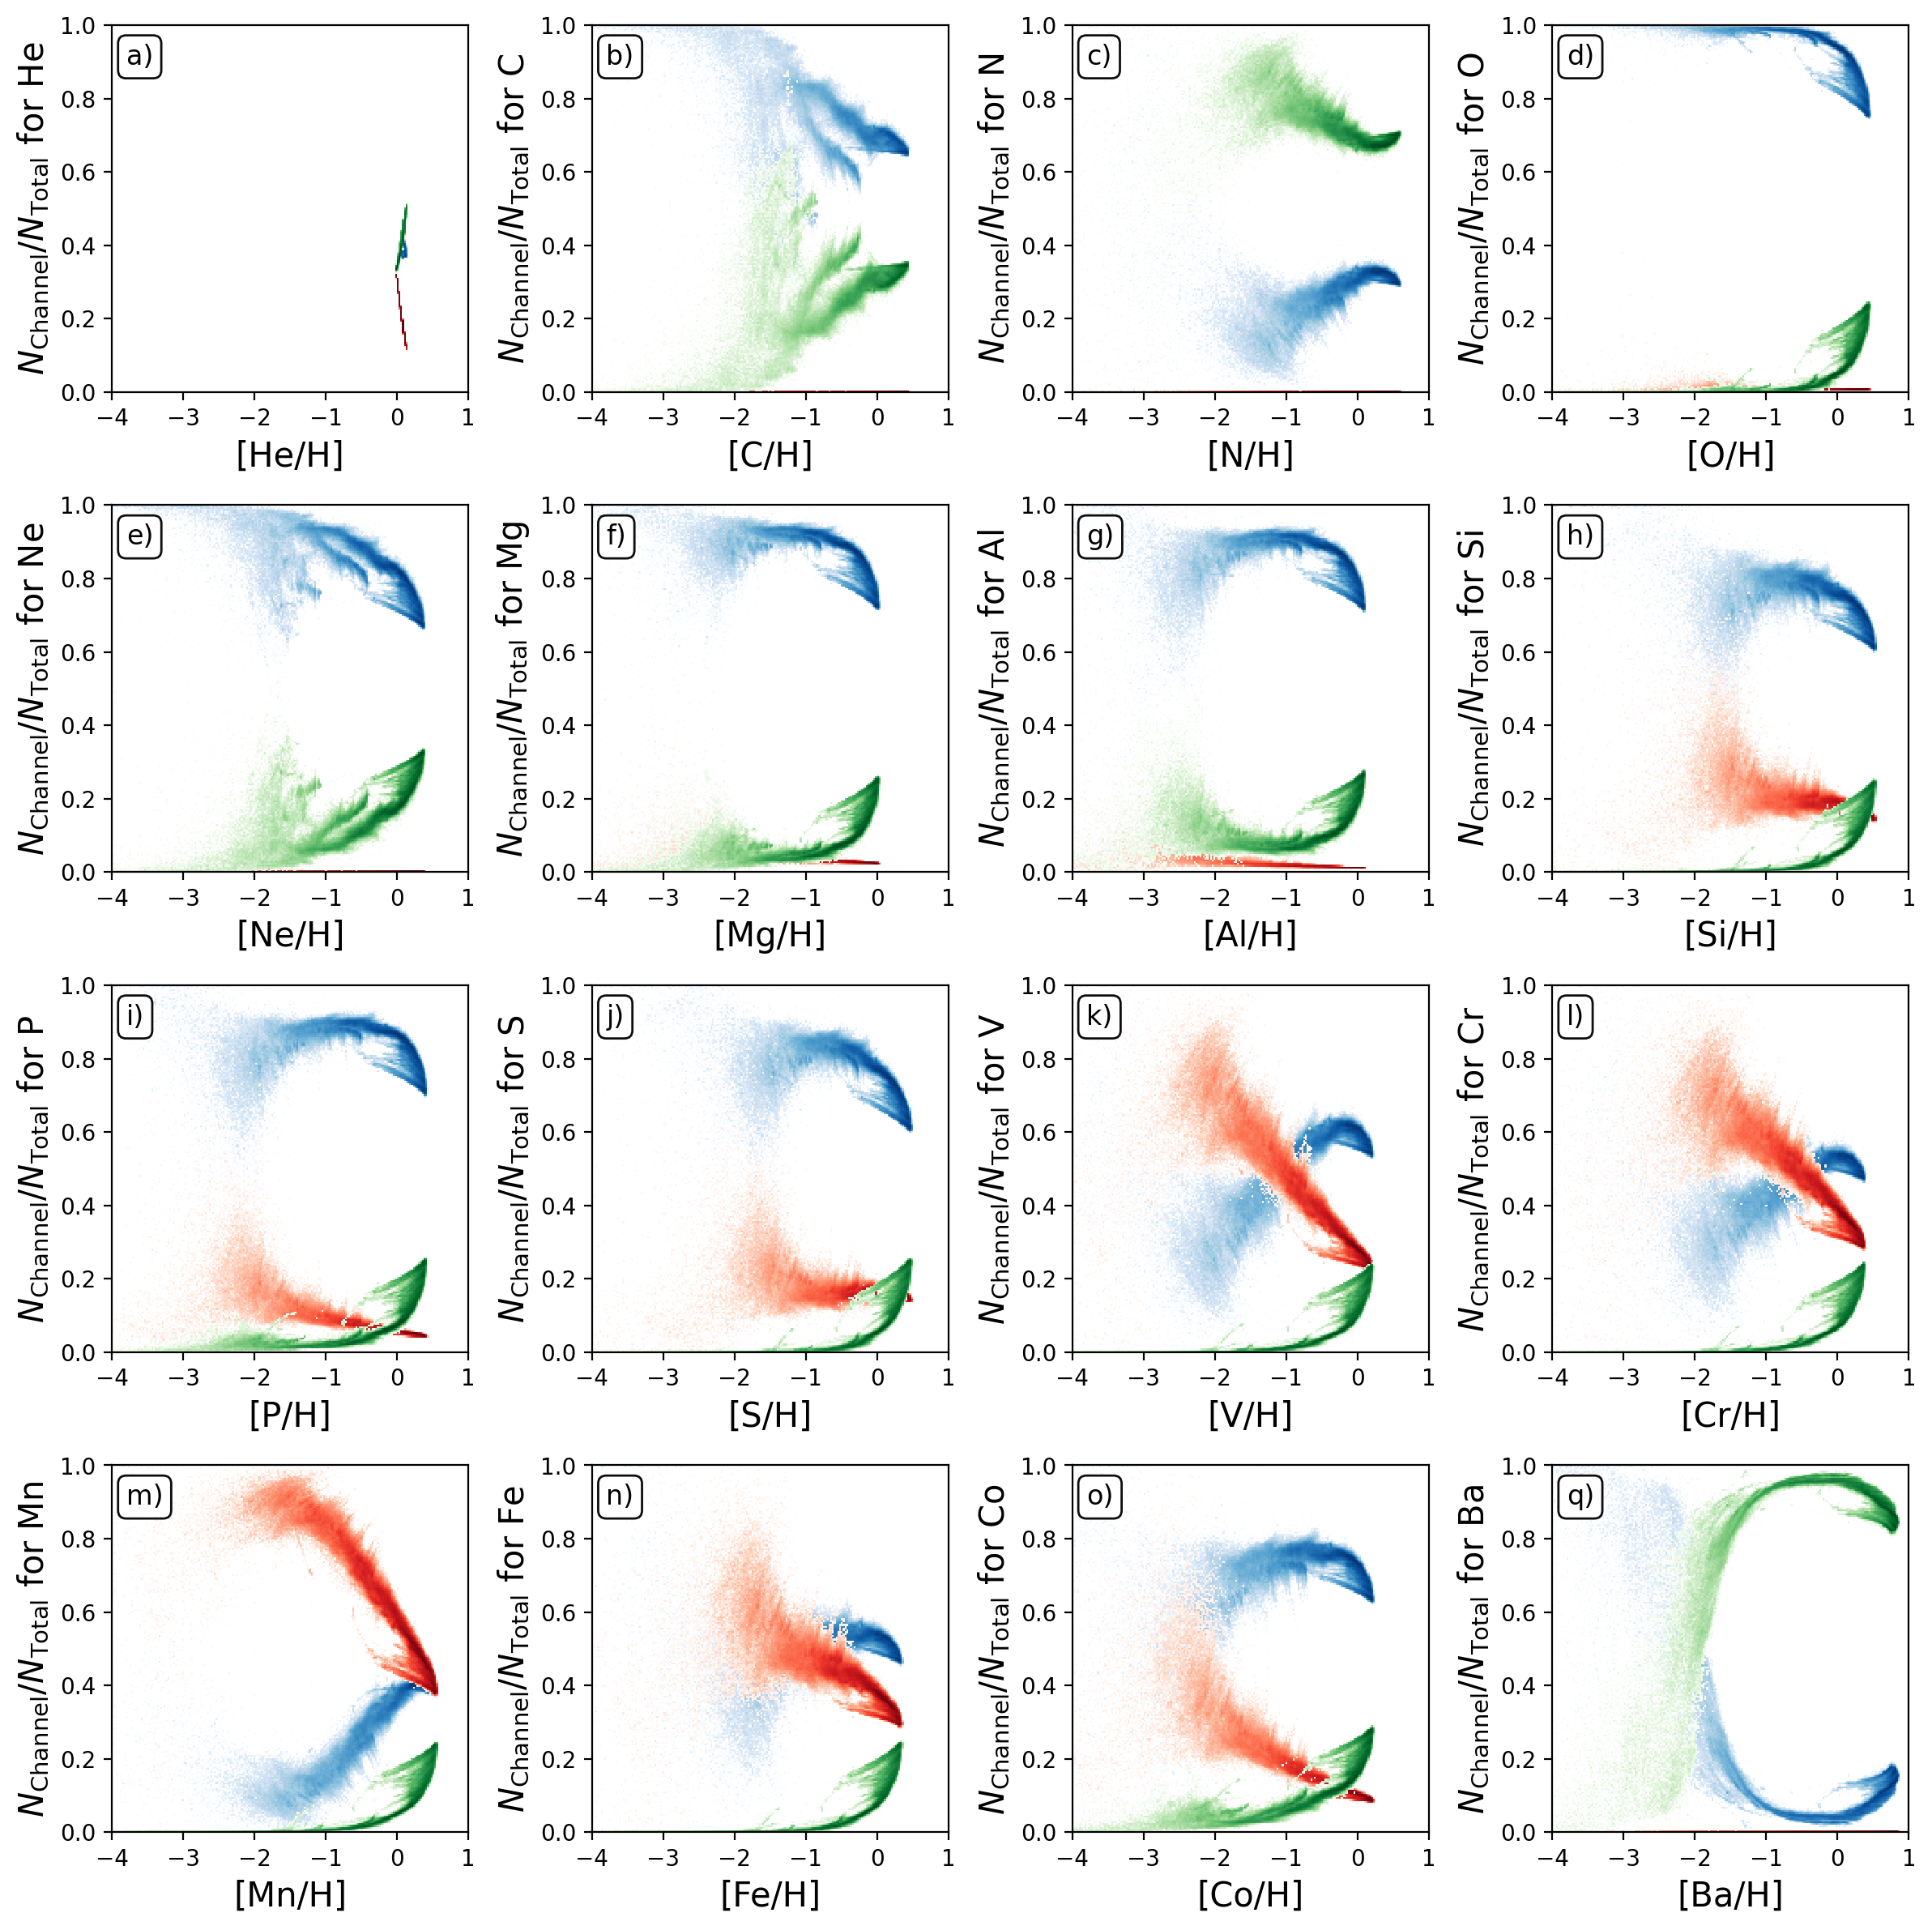

In [9]:
def plot_channel_contributions_over_x_h(ymin = -6.0, ymax = 1.0, bins = 200, saveas=False):    
    
    rows, cols = optimal_grid(len(elements_in_simulation))
    
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols,3*rows))
    axes = axes.flatten()
    
    for i, element in enumerate(elements_in_simulation):
        
        ax = axes[i]
        ax.text(0.04,0.95,panels[i],fontsize=12,transform=ax.transAxes,va='top',ha='left',bbox=dict(boxstyle='round', facecolor='w', alpha=0.95))
        ax.set_xlabel('['+element+'/H]',fontsize=15)
        ax.set_ylabel(r'$N_\mathrm{Channel} / N_\mathrm{Total}$ for '+element,fontsize=15)

        for colormap, channel in zip(['Blues','Reds','Greens'],['SNII','SNIa','AGB']):
            ax.hist2d(
                stars[element+'_H'],
                (10**stars[element+'_H_'+channel]) / (10**stars[element+'_H']),
                bins = (np.linspace(-4,1,bins),np.linspace(0,1, bins)), cmin = 1, norm=LogNorm(),
                cmap = colormap
            );
    plt.tight_layout()

    if saveas:
        filename = simulation_name+'_nucleosynthesis_channels_xh.png'
        plt.savefig('figures/'+filename, dpi=400, bbox_inches='tight')
        print('Saved as '+filename)
    plt.show()
    plt.close()

plot_channel_contributions_over_x_h()

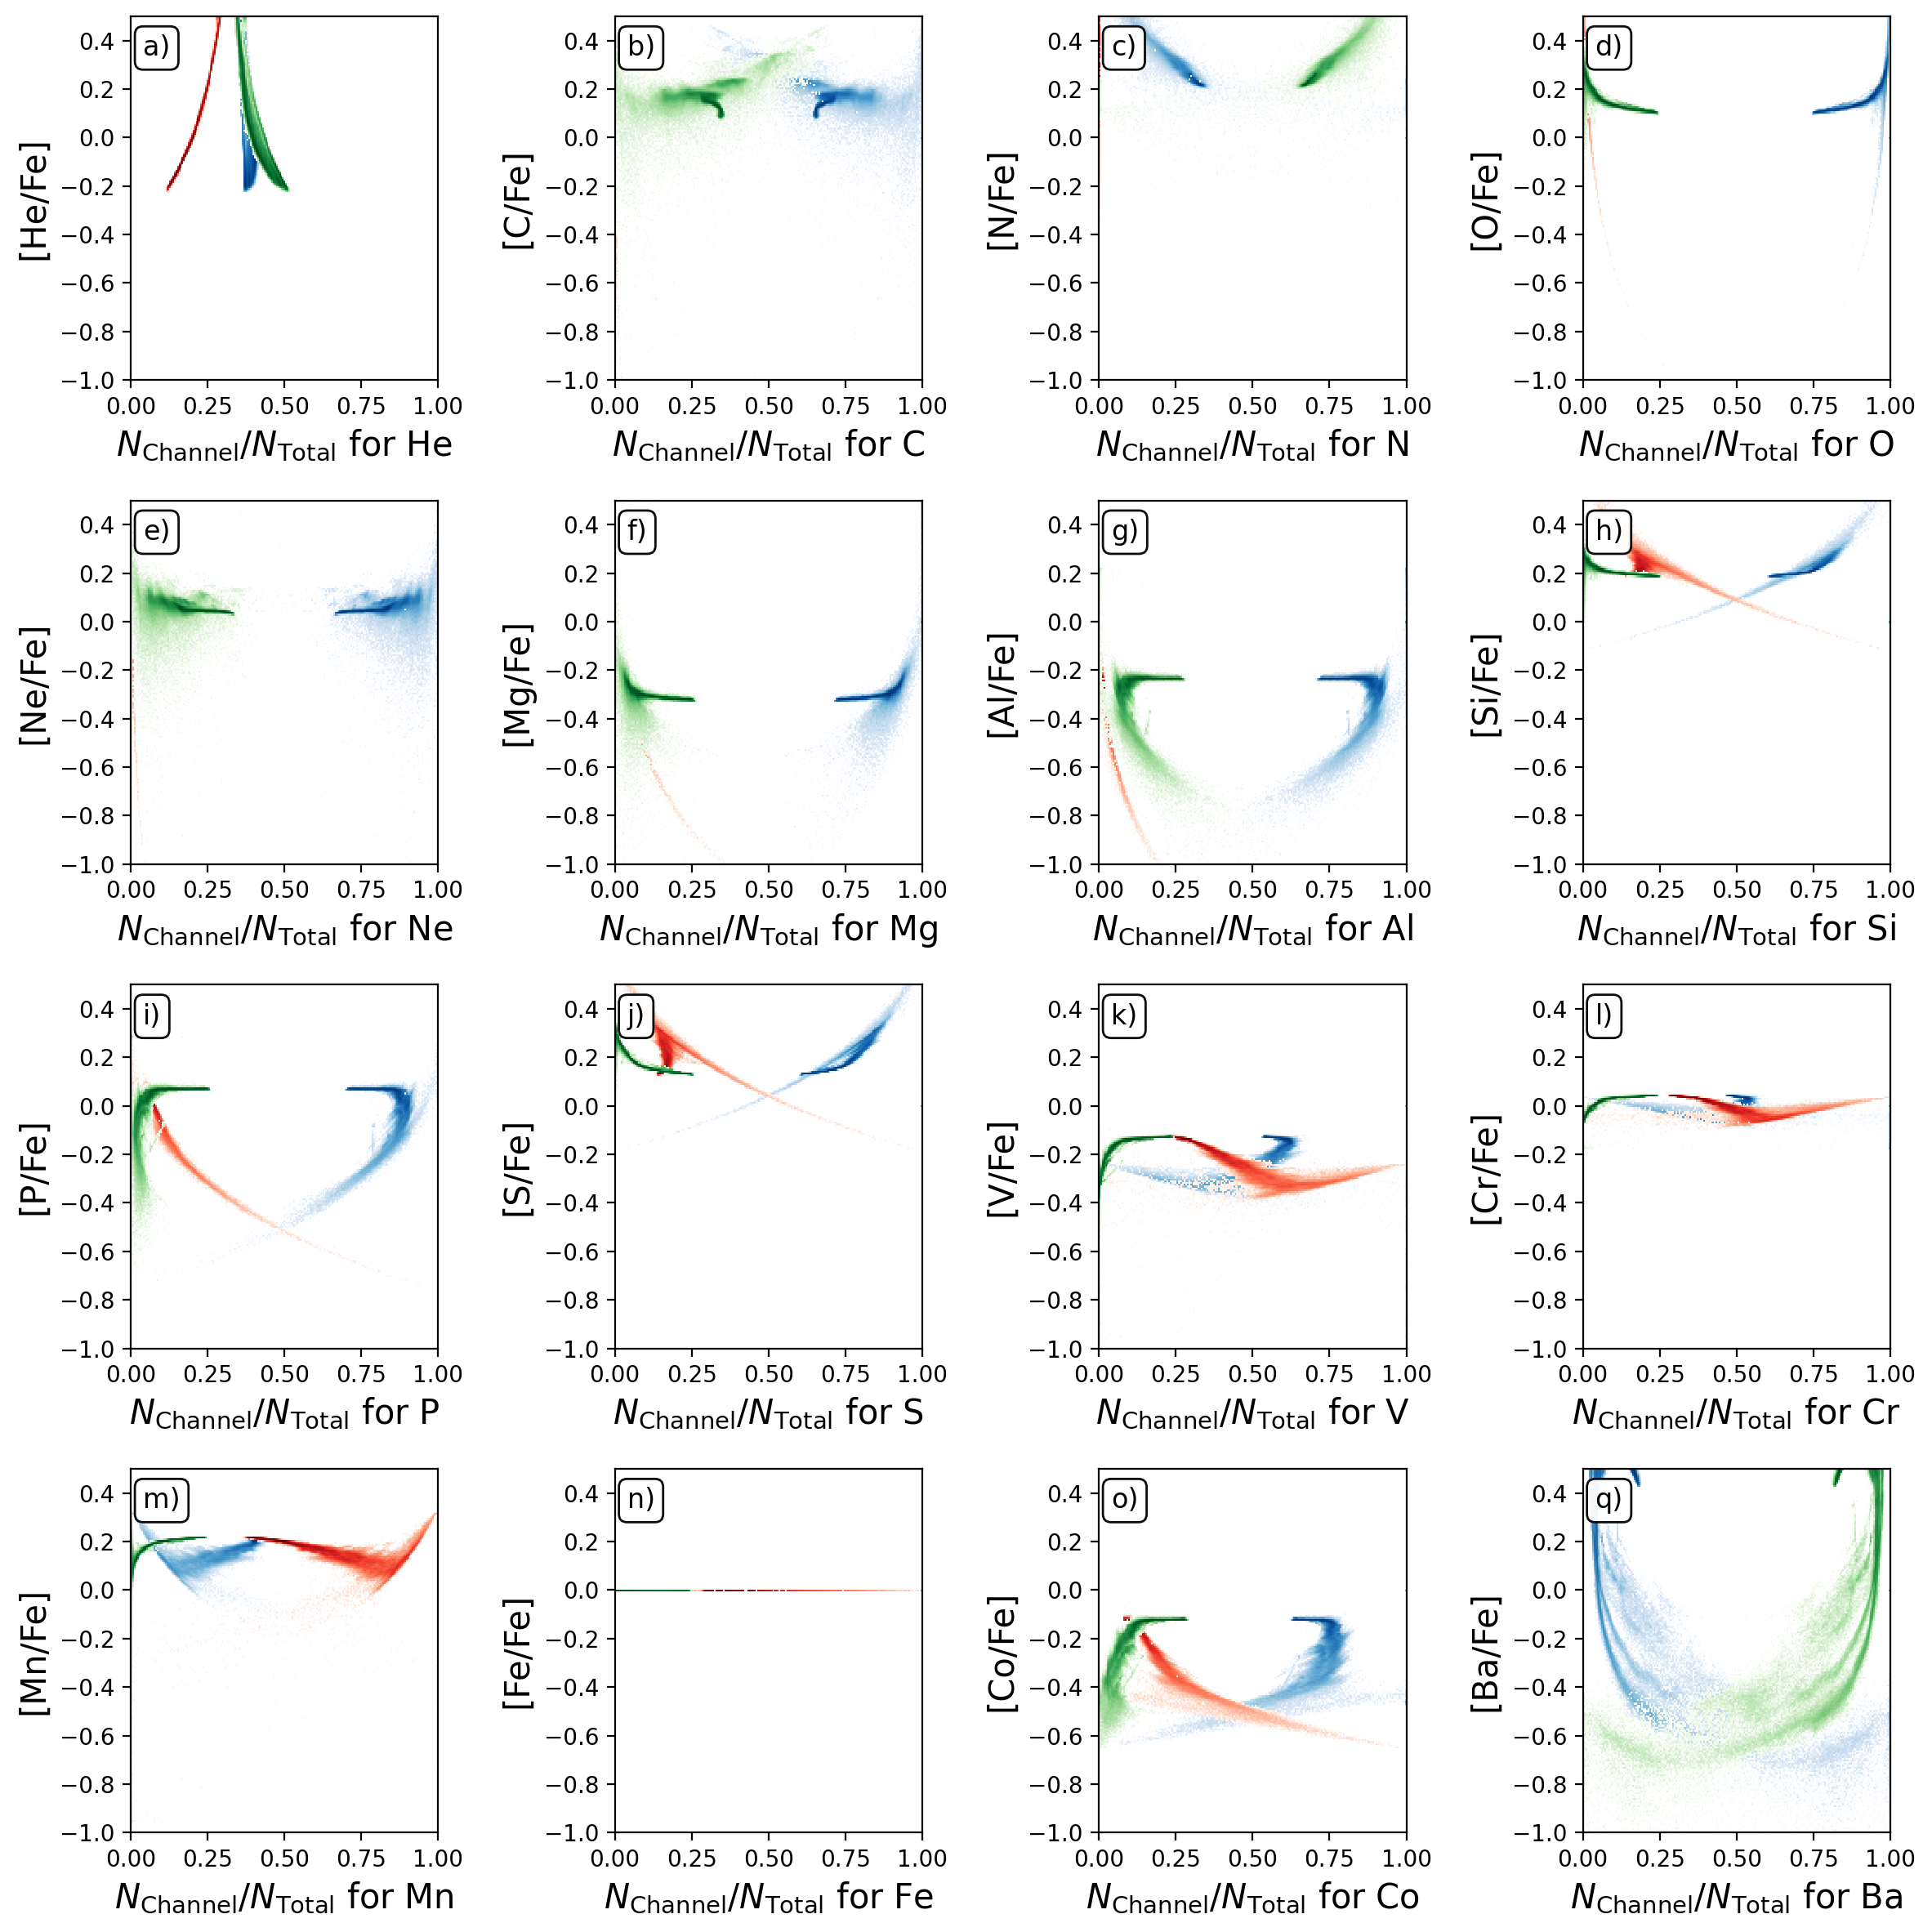

In [10]:
def plot_channel_contributions_over_x_fe(bins = 200, saveas=False):    
    
    rows, cols = optimal_grid(len(elements_in_simulation))
    
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols,3*rows))
    axes = axes.flatten()
    
    for i, element in enumerate(elements_in_simulation):
        
        ax = axes[i]
        ax.text(0.04,0.95,panels[i],fontsize=12,transform=ax.transAxes,va='top',ha='left',bbox=dict(boxstyle='round', facecolor='w', alpha=0.95))
        ax.set_xlabel(r'$N_\mathrm{Channel} / N_\mathrm{Total}$ for '+element,fontsize=15)
        ax.set_ylabel('['+element+'/Fe]',fontsize=15)

        for colormap, channel in zip(['Blues','Reds','Greens'],['SNII','SNIa','AGB']):
            ax.hist2d(
                (10**stars[element+'_H_'+channel]) / (10**stars[element+'_H']),
                stars[element+'_H']-stars['Fe_H'],
                bins = (np.linspace(0,1, bins),np.linspace(-1,0.5,bins)), cmin = 1, norm=LogNorm(),
                cmap = colormap
            );
    plt.tight_layout()

    if saveas:
        filename = simulation_name+'_nucleosynthesis_channels_xfe.png'
        plt.savefig('figures/'+filename, dpi=400, bbox_inches='tight')
        print('Saved as '+filename)
    plt.show()
    plt.close()

plot_channel_contributions_over_x_fe()